Running 15-Fold CV for CatBoost...
CatBoost Metrics -> ACC: 0.933±0.027 | AUC: 0.979±0.015 | F1: 0.855±0.061


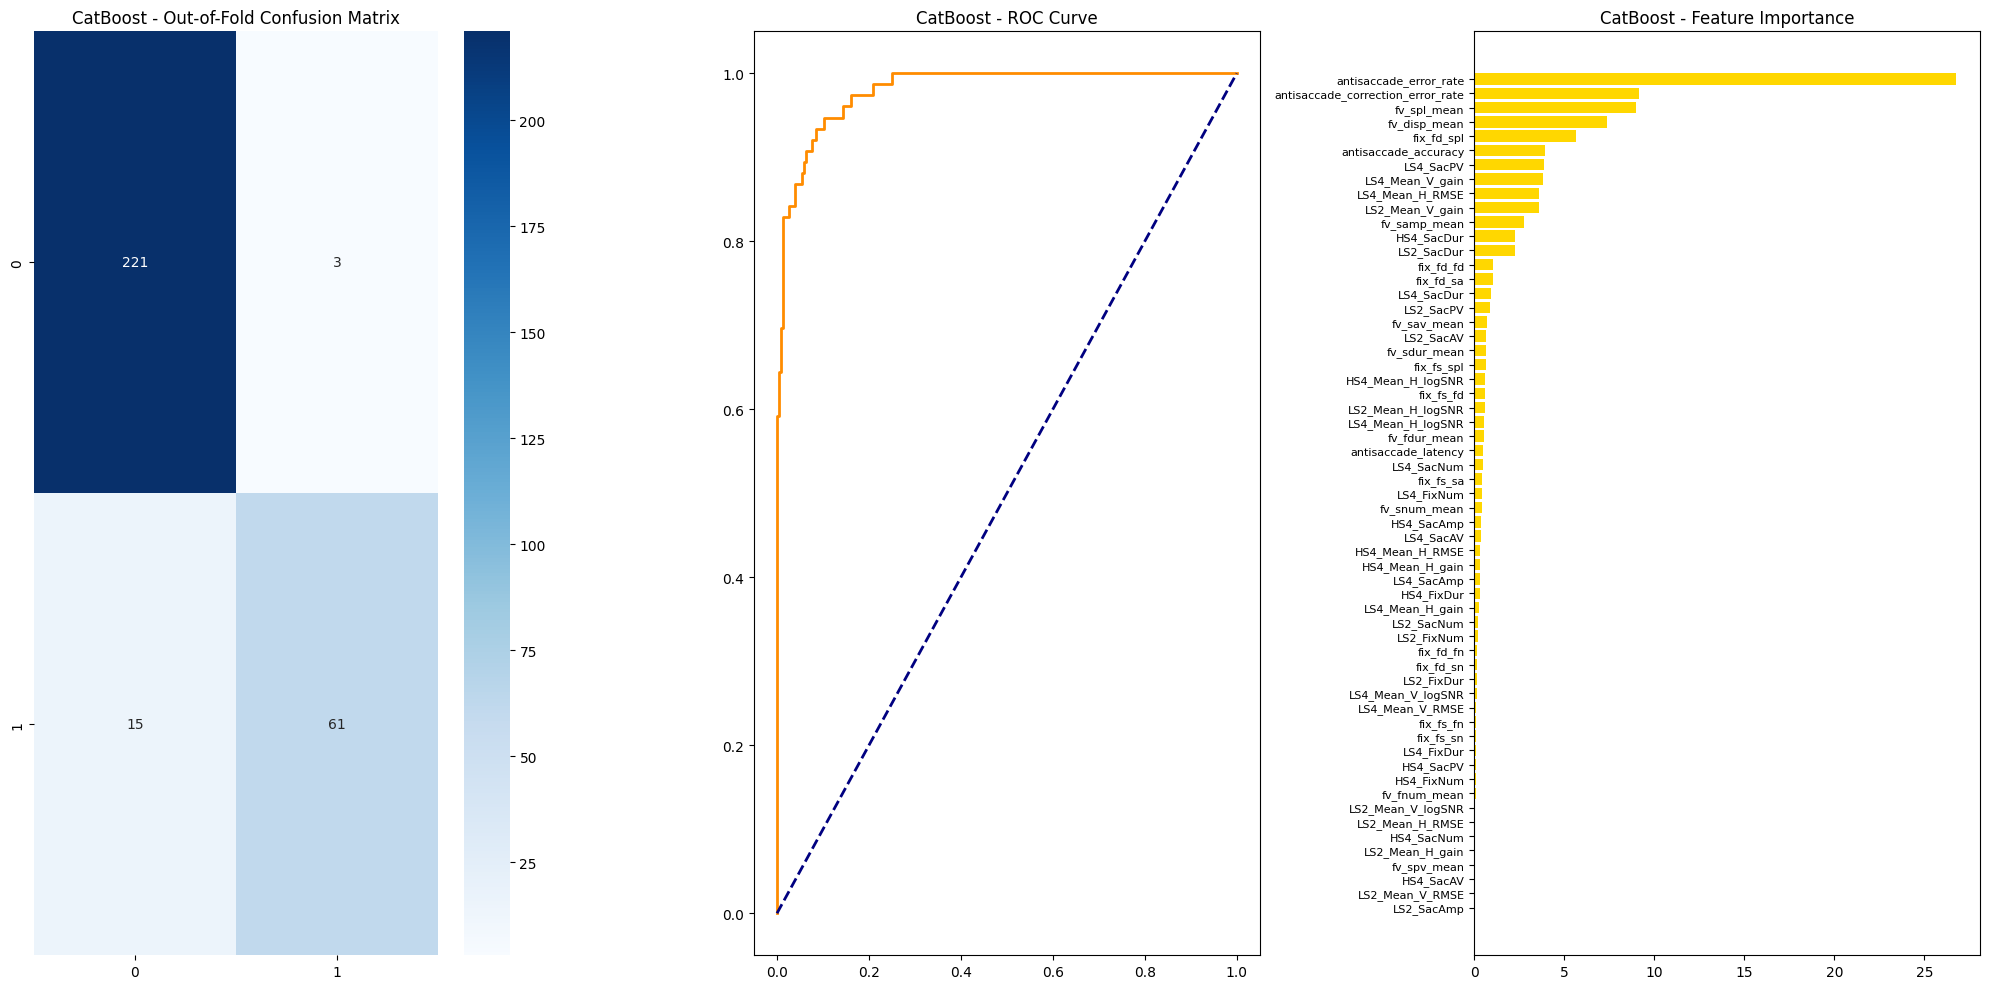

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, confusion_matrix
from catboost import CatBoostClassifier

df = pd.read_csv('synthetic_eye_tracking_HC_SZ_300.csv')
X = df.drop(columns=['subject_id', 'label', 'calibration_error'])
y = LabelEncoder().fit_transform(df['label'])
feature_names = X.columns.tolist()

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
accs, aucs, f1s = [], [], []

print("Running 15-Fold CV for CatBoost...")
for train_idx, val_idx in rskf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    model = CatBoostClassifier(depth=3, iterations=300, verbose=0, random_state=42)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]
    
    accs.append(accuracy_score(y_val, preds))
    aucs.append(roc_auc_score(y_val, probs))
    f1s.append(f1_score(y_val, preds))

print(f"CatBoost Metrics -> ACC: {np.mean(accs):.3f}±{np.std(accs):.3f} | AUC: {np.mean(aucs):.3f}±{np.std(aucs):.3f} | F1: {np.mean(f1s):.3f}±{np.std(f1s):.3f}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds, oof_probs = np.zeros(len(y)), np.zeros(len(y))

for train_idx, val_idx in skf.split(X, y):
    model = CatBoostClassifier(depth=3, iterations=300, verbose=0, random_state=42)
    model.fit(X.iloc[train_idx], y[train_idx])
    oof_preds[val_idx] = model.predict(X.iloc[val_idx])
    oof_probs[val_idx] = model.predict_proba(X.iloc[val_idx])[:, 1]

pd.DataFrame({'subject_id': df['subject_id'], 'actual_label': y, 'predicted_label': oof_preds, 'predicted_prob': oof_probs, 'calibration_error': df['calibration_error']}).to_csv('predictions_catboost.csv', index=False)

final_model = CatBoostClassifier(depth=3, iterations=300, verbose=0, random_state=42)
final_model.fit(X, y)
final_model.save_model('model_catboost.cbm')

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
sns.heatmap(confusion_matrix(y, oof_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("CatBoost - Out-of-Fold Confusion Matrix")

fpr, tpr, _ = roc_curve(y, oof_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title("CatBoost - ROC Curve")

importances = final_model.get_feature_importance()
indices = np.argsort(importances)

axes[2].barh(range(len(indices)), importances[indices], color='gold')
axes[2].set_yticks(range(len(indices)))
axes[2].set_yticklabels([feature_names[i] for i in indices], fontsize=8)
axes[2].set_title("CatBoost - Feature Importance")
plt.tight_layout()
plt.show()